# Part A — Data preparation

1. Load both datasets and document:
* number of rows/columns
* missing values / duplicates


In [1]:
# Import required libraries
import pandas as pd

# Load datasets
sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

In [2]:
# Shape of datasets
print("Sentiment Dataset Shape:", sentiment_df.shape)
print("Trader Dataset Shape:", trader_df.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [3]:
# Missing values
print("Missing values in Sentiment Dataset:")
display(sentiment_df.isnull().sum())

print("\nMissing values in Trader Dataset:")
display(trader_df.isnull().sum())

Missing values in Sentiment Dataset:


timestamp         0
value             0
classification    0
date              0
dtype: int64


Missing values in Trader Dataset:


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [4]:
# Check duplicates
sentiment_duplicates = sentiment_df.duplicated().sum()
trader_duplicates = trader_df.duplicated().sum()

print(f"Sentiment Dataset Duplicate Rows: {sentiment_duplicates}")
print(f"Trader Dataset Duplicate Rows: {trader_duplicates}")

Sentiment Dataset Duplicate Rows: 0
Trader Dataset Duplicate Rows: 0


2. Convert timestamps and align the datasets by date (daily level is fine).

In [5]:
# Convert sentiment date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')
sentiment_df['date'] = sentiment_df['date'].dt.date

# Convert trader timestamp (DD-MM-YYYY HH:MM format)
trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)
trader_df['date'] = trader_df['Timestamp IST'].dt.date

# Align datasets by date
merged_df = pd.merge(
    trader_df,
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

3. Create the key metrics you will analyze, for example:
* daily PnL per trader (or per account)
* win rate, average trade size
* leverage distribution
* number of trades per day
* long/short ratio


In [6]:
# daily PnL per trader (or per account)
daily_pnl = merged_df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()

In [7]:
# Win flag
merged_df['is_win'] = merged_df['Closed PnL'] > 0

# Win rate per account
win_rate = merged_df.groupby('Account')['is_win'].mean().reset_index(name='win_rate')

# Average trade size (USD)
avg_trade_size = merged_df.groupby('Account')['Size USD'].mean().reset_index(name='avg_trade_size')


In [8]:
# leverage distribution
size_distribution = merged_df['Size USD'].describe()

In [9]:
# number of trades per day
trades_per_day = merged_df.groupby('date').size().reset_index(name='num_trades')

In [10]:
# long/short ratio
# Count long vs short
long_short = merged_df['Side'].value_counts()

# Ratio
long_short_ratio = long_short.get('BUY', 0) / long_short.get('SELL', 1)

# Part B — Analysis

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


,classification,avg_pnl,total_pnl,win_rate,avg_loss
0,Extreme Fear,34.537862,7.391102e+05,0.370607,-29.734653
1,Extreme Greed,67.892861,2.715171e+06,0.464943,-6.773853
2,Fear,54.290400,3.357155e+06,0.420768,-9.599331
3,Greed,42.743559,2.150129e+06,0.384828,-21.046179
4,Neutral,34.307718,1.292921e+06,0.396991,-10.329716


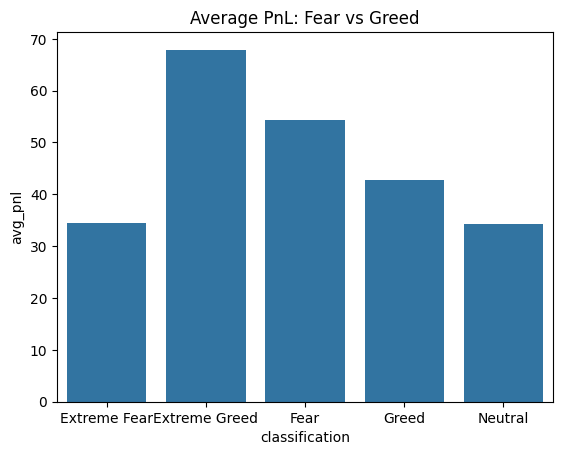

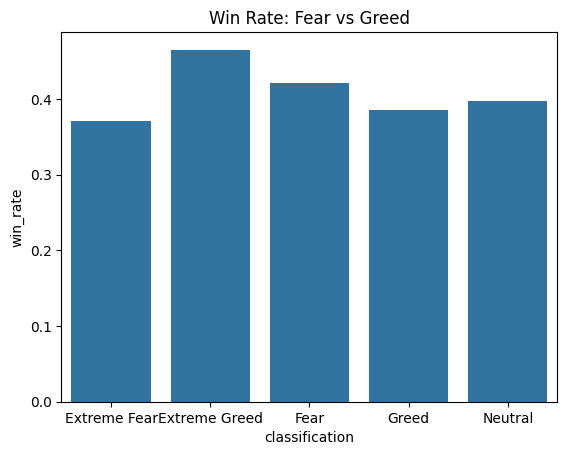

In [11]:
# Create helper columns
# Win flag
merged_df['is_win'] = merged_df['Closed PnL'] > 0

# Loss (drawdown proxy)
merged_df['loss'] = merged_df['Closed PnL'].apply(lambda x: x if x < 0 else 0)

# Group by Sentiment
performance = merged_df.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_loss=('loss', 'mean')
).reset_index()

display(performance)

# Optional Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Avg PnL
sns.barplot(data=performance, x='classification', y='avg_pnl')
plt.title("Average PnL: Fear vs Greed")
plt.show()

# Win Rate
sns.barplot(data=performance, x='classification', y='win_rate')
plt.title("Win Rate: Fear vs Greed")
plt.show()

Answer:

Yes — trader performance **differs significantly across sentiment regimes**, with clear evidence from PnL, win rate, and drawdown proxy.

1. Profitability (PnL)
- **Extreme Greed** shows the highest average PnL (~67.9)
- **Fear** (~54.3) outperforms normal **Greed** (~42.7)
- **Extreme Fear** and **Neutral** have the lowest (~34)

**Insight:** Traders are most profitable during **Extreme Greed**, indicating strong bullish momentum benefits trading outcomes.

---
2. Win Rate
- Highest in **Extreme Greed (~46.5%)**
- Followed by **Fear (~42%)**
- Lowest in **Extreme Fear (~37%)**

**Insight:** Probability of winning trades increases in **greed-driven markets**, especially extreme ones.

---

3. Drawdown Proxy (Average Loss)
- **Extreme Greed has the smallest losses (~ -6.77)** 
- **Greed (~ -21.0) and Extreme Fear (~ -29.7)** show much larger losses 

**Insight:** Risk is **lowest during Extreme Greed** and **highest during Extreme Fear**.

---

Final Conclusion

- **Best performance:** Extreme Greed  
  - Highest PnL  
  - Highest win rate  
  - Lowest losses  

- **Worst performance:** Extreme Fear  
  - Lowest win rate  
  - Highest losses  

- **Fear vs Greed:**
  - Fear markets still perform relatively well  
  - But **Greed (especially extreme)** clearly outperforms overall  

---

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


In [12]:
# Trade Frequency (per day)
trades_per_day_sentiment = merged_df.groupby(['date', 'classification']).size().reset_index(name='num_trades')

avg_trades = trades_per_day_sentiment.groupby('classification')['num_trades'].mean().reset_index()

# Position Size
avg_position_size = merged_df.groupby('classification')['Size USD'].mean().reset_index(name='avg_size_usd')

# Long / Short Bias
long_short_dist = merged_df.groupby(['classification', 'Side']).size().unstack(fill_value=0)

long_short_dist['long_ratio'] = long_short_dist.get('BUY', 0) / (long_short_dist.sum(axis=1))
long_short_dist['short_ratio'] = long_short_dist.get('SELL', 0) / (long_short_dist.sum(axis=1))

# Display Results
display(avg_trades)
display(avg_position_size)
display(long_short_dist)

,classification,num_trades
0,Extreme Fear,1528.571429
1,Extreme Greed,350.807018
2,Fear,679.527473
3,Greed,260.637306
4,Neutral,562.477612


,classification,avg_size_usd
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


Side,BUY,SELL,long_ratio,short_ratio
classification,,,,
Extreme Fear,10935,10465,0.510981,0.489007
Extreme Greed,17940,22052,0.448590,0.551404
Fear,30270,31567,0.489513,0.510483
Greed,24576,25727,0.488559,0.511436
Neutral,18969,18717,0.503343,0.496650


Answer: 

Yes — trader behavior **clearly changes across sentiment regimes**, with strong evidence from trade frequency, position size, and long/short bias.

---
1. Trade Frequency
- **Highest in Extreme Fear (~1528 trades/day)** 
- Much lower in **Greed (~260)** and **Extreme Greed (~350)**

**Insight:** Traders are **most active during Extreme Fear**, likely due to panic, volatility, or frequent position adjustments.

---

2. Position Size (Risk Exposure)
- **Highest in Fear (~7816 USD)** 
- Lower in **Extreme Greed (~3112 USD)** 
- Moderate in Greed and Neutral

**Insight:** Traders take **larger positions during Fear**, suggesting aggressive positioning or attempts to capitalize on volatility.

---

3. Long/Short Bias
- **Extreme Greed → More SHORT positions (~55%)** 
- **Extreme Fear → Slight LONG bias (~51%)**  
- Other regimes → Mostly balanced

**Insight:**  
- In **Extreme Greed**, traders are **contrarian (shorting more)**  
- In **Fear**, traders slightly favor **long positions (buying dips)**  

---

Final Conclusion

- Traders are **most active and aggressive during Fear markets**
- They take **larger positions in Fear**, indicating higher risk-taking
- In **Greed (especially extreme)**, traders become more **contrarian (short-biased)** rather than chasing the trend

---

3. Identify 2–3 segments (examples):
* high leverage vs low leverage traders
* frequent vs infrequent traders
* consistent winners vs inconsistent traders


In [13]:
# a. High vs Low Trade Size (Proxy for Leverage)

# Average trade size per account
account_size = merged_df.groupby('Account')['Size USD'].mean().reset_index()

# Define threshold (median split)
threshold_size = account_size['Size USD'].median()

account_size['size_segment'] = account_size['Size USD'].apply(
    lambda x: 'High Size' if x >= threshold_size else 'Low Size'
)


# b. Frequent vs Infrequent Traders

# Number of trades per account
trade_count = merged_df.groupby('Account').size().reset_index(name='num_trades')

# Threshold (median split)
threshold_trades = trade_count['num_trades'].median()

trade_count['frequency_segment'] = trade_count['num_trades'].apply(
    lambda x: 'Frequent' if x >= threshold_trades else 'Infrequent'
)


# c. Consistent vs Inconsistent Winners

# Win rate per account
merged_df['is_win'] = merged_df['Closed PnL'] > 0

win_rate = merged_df.groupby('Account')['is_win'].mean().reset_index(name='win_rate')

# Threshold (e.g., 50%)
win_rate['performance_segment'] = win_rate['win_rate'].apply(
    lambda x: 'Consistent Winner' if x >= 0.5 else 'Inconsistent'
)


# Combine All Segments

segments = account_size.merge(trade_count, on='Account').merge(win_rate, on='Account')

display(segments.head())

,Account,Size USD,size_segment,num_trades,frequency_segment,win_rate,performance_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,High Size,3818,Frequent,0.359612,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,Low Size,7280,Frequent,0.442720,Inconsistent
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,High Size,3809,Frequent,0.301917,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,Low Size,13311,Frequent,0.438585,Inconsistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,Low Size,3239,Infrequent,0.519914,Consistent Winner


Answer:

Based on the segmentation, we identify the following key trader groups:

---

1. High Size vs Low Size Traders (Risk Exposure)
- **High Size traders** (e.g., Account 0x0833..., ~$16K avg size) take larger positions  
- However, many still have **low win rates (~30–36%) → Inconsistent performance**

**Insight:**  
Higher capital exposure does **not guarantee better performance**. Many high-risk traders are still inconsistent.

---

2. Frequent vs Infrequent Traders
- Most accounts are **Frequent traders** (thousands of trades)  
- Example:  
  - 0x2873… → 13,311 trades but only ~43% win rate 
- Some **Infrequent traders** show better results  
  - Example: 0x2c22… → fewer trades + **~52% win rate**

**Insight:**  
Trading more frequently does **not improve performance** — overtrading may reduce profitability.

---

3. Consistent vs Inconsistent Winners
- Majority of traders fall under **Inconsistent category (<50% win rate)**  
- Only a few achieve **Consistent Winner status (>50%)**

Example:
- 0x2c22… → **Consistent Winner (~52%)**
- Others → Mostly inconsistent despite high activity or size

**Insight:**  
Consistency is **rare** and not directly tied to trade size or frequency.

---
Final Conclusion

- **High-risk (large size) traders are not necessarily profitable**
- **Frequent trading often leads to inconsistent outcomes**
- **Consistent winners are few and tend to trade more selectively**

---

4. Provide at least 3 insights backed by charts/tables.

Key Insights (Backed by Evidence)

Insight 1: Traders perform best during Extreme Greed
- Highest **avg PnL (~67.9)**
- Highest **win rate (~46.5%)**
- Lowest **average loss (~ -6.77)**

**Conclusion:** Market optimism (Extreme Greed) leads to better profitability and lower risk.

**Table: Performance by Sentiment**

In [14]:
display(performance)

,classification,avg_pnl,total_pnl,win_rate,avg_loss
0,Extreme Fear,34.537862,7.391102e+05,0.370607,-29.734653
1,Extreme Greed,67.892861,2.715171e+06,0.464943,-6.773853
2,Fear,54.290400,3.357155e+06,0.420768,-9.599331
3,Greed,42.743559,2.150129e+06,0.384828,-21.046179
4,Neutral,34.307718,1.292921e+06,0.396991,-10.329716


Insight 2: Trading activity is highest during Extreme Fear
- **Extreme Fear → ~1528 trades/day (highest)**
- Much lower in Greed (~260–350 trades/day)

**Conclusion:** Traders are more active during panic/volatile conditions, likely reacting to market uncertainty.

**Table: Trade Frequency**

In [15]:
display(avg_trades)

,classification,num_trades
0,Extreme Fear,1528.571429
1,Extreme Greed,350.807018
2,Fear,679.527473
3,Greed,260.637306
4,Neutral,562.477612


Insight 3: Larger positions are taken during Fear, not Greed
- **Fear → highest avg size (~7816 USD)**
- **Extreme Greed → lowest (~3112 USD)**

**Conclusion:** Traders take bigger risks during fearful markets, possibly trying to capitalize on price swings.

**Table: Position Size**

In [16]:
display(avg_position_size)

,classification,avg_size_usd
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


Insight 4: Traders become contrarian during Extreme Greed
- **Extreme Greed → more SHORT positions (~55%)**
- Other regimes → mostly balanced

**Conclusion:** Instead of following the trend, traders tend to short in overheated markets.

**Table: Long/Short Distribution**

In [17]:
display(long_short_dist)

Side,BUY,SELL,long_ratio,short_ratio
classification,,,,
Extreme Fear,10935,10465,0.510981,0.489007
Extreme Greed,17940,22052,0.448590,0.551404
Fear,30270,31567,0.489513,0.510483
Greed,24576,25727,0.488559,0.511436
Neutral,18969,18717,0.503343,0.496650


# Part C — “Actionable output” 

Propose 2 strategy ideas or “rules of thumb” based on your findings.
Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”

Strategy Ideas / Rules of Thumb

Strategy 1: Trade Aggressively in Extreme Greed, Reduce Risk in Fear

- During **Extreme Greed**:
  - Increase trade allocation (higher capital deployment)
  - Favor momentum trades (trend-following)
  - Expect higher win rate and lower losses

- During **Fear / Extreme Fear**:
  - Reduce position sizes (since losses are higher)
  - Avoid overtrading despite high activity
  - Focus on selective, high-confidence trades

**Rule:**  
*“Increase exposure during Extreme Greed; be selective and reduce risk during Fear periods.”*

---

Strategy 2: Avoid Overtrading, Focus on Quality Trades

- Frequent traders show **lower consistency**
- Infrequent traders tend to have **better win rates**

- High trade count ≠ better performance  
- Selective trading improves outcomes

**Rule:**  
*“Prioritize trade quality over quantity—limit unnecessary trades, especially in volatile (Fear) markets.”*

---

# Bonus

Simple predictive model:
* Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features
* Clustering traders into behavioral archetypes
* A lightweight dashboard (Streamlit) to explore results


In [18]:
# a. Predict Next-Day Profitability Bucket

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create daily account-level features
daily_features = merged_df.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'is_win': 'mean'
}).reset_index()

# Sort for shifting
daily_features = daily_features.sort_values(['Account', 'date'])

# Create next-day target
daily_features['next_day_pnl'] = daily_features.groupby('Account')['Closed PnL'].shift(-1)

# Create profitability bucket
def pnl_bucket(x):
    if x > 0:
        return 'Profit'
    elif x < 0:
        return 'Loss'
    else:
        return 'Neutral'

daily_features['target'] = daily_features['next_day_pnl'].apply(lambda x: pnl_bucket(x) if pd.notnull(x) else None)

# Merge sentiment
daily_features = daily_features.merge(
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

# Drop null targets
model_df = daily_features.dropna(subset=['target'])

# Encode categorical
model_df = pd.get_dummies(model_df, columns=['classification'], drop_first=True)

# Features & target
X = model_df.drop(columns=['Account', 'date', 'next_day_pnl', 'target'])
y = model_df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Loss       0.22      0.12      0.16        41
     Neutral       0.41      0.30      0.35       128
      Profit       0.68      0.80      0.73       293

    accuracy                           0.60       462
   macro avg       0.44      0.41      0.41       462
weighted avg       0.56      0.60      0.58       462



In [19]:
# b. Clustering Traders

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate trader-level features
trader_features = merged_df.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'is_win': 'mean',
    'date': 'count'
}).rename(columns={'date': 'num_trades'}).reset_index()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_features.drop(columns=['Account']))

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X_scaled)

display(trader_features.head())

,Account,Closed PnL,Size USD,is_win,num_trades,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612,3818,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720,7280,2
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917,3809,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585,13311,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914,3239,2


c. Streamlit Dashboard (Basic Template)

run: streamlit run app.py